Loading HadGEM PPE...
  HadGEM members: 1515
    GA7: 509 members
    GA8: 503 members
    GA9: 503 members
Loading CMIP6 (one member per model)...
  CMIP6 models: 44
Loading AMIP (one member per model)...
  AMIP models: 11
Computing spatial correlations (with area weighting)...


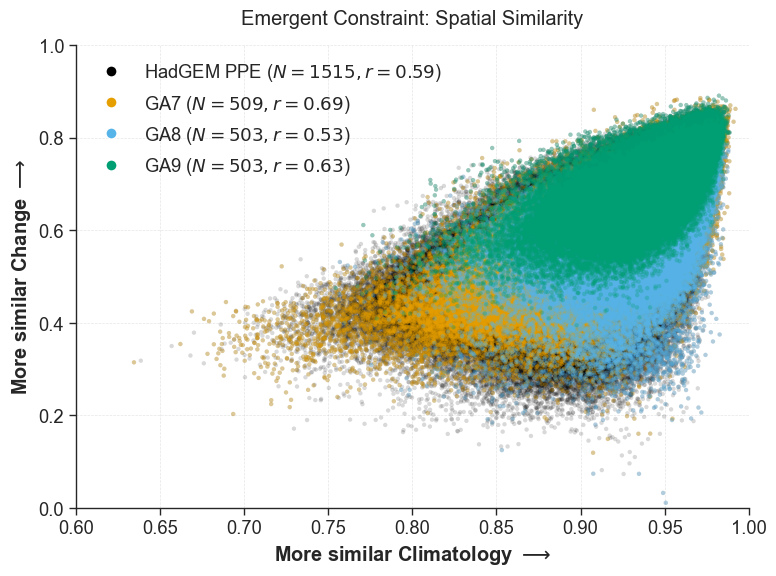

Done.


In [4]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# Config & Style
# ==============================================================================
sns.set_context("paper", font_scale=1.5)
sns.set_style("ticks")

LAT_DIM = 128

# Toggle: color within-family HadGEM pairs by GA family on top of the gray cloud
SHOW_GA_COLORS = True

GA_COLORS = {
    "GA7": "#E69F00",   # orange
    "GA8": "#56B4E9",   # sky blue
    "GA9": "#009E73",   # bluish green
}

# ---- paths ----
HG_DIR    = Path("/Users/ewellmeyer/Documents/research/HadGEM")
CMIP6_DIR = Path(f"/Users/ewellmeyer/Documents/research/CMIP6/regridded/rg_{LAT_DIM}x192")
AMIP_DIR  = Path(f"/Users/ewellmeyer/Documents/research/AMIP/regridded/rg_{LAT_DIM}x192")

# ==============================================================================
# Utilities
# ==============================================================================
def get_area_weights(lat_dim=128, lon_dim=192):
    """
    Compute area weights based on latitude (cosine weighting).
    Returns a 1D array that can be used to weight flattened spatial fields.
    """
    # Create latitude array (assuming uniform spacing from -90 to 90)
    lats = np.linspace(-90, 90, lat_dim)
    lat_rad = np.deg2rad(lats)
    
    # Cosine weights for each latitude band
    cos_weights = np.cos(lat_rad)
    
    # Tile across longitudes to create 2D weight array, then flatten
    weights_2d = np.tile(cos_weights[:, np.newaxis], (1, lon_dim))
    weights_1d = weights_2d.ravel()
    
    # Normalize so weights sum to 1
    weights_1d = weights_1d / weights_1d.sum()
    
    return weights_1d

def pairwise_spatial_corr(arr, weights=None):
    """
    arr : (N, P) array of flattened spatial fields
    weights : (P,) array of weights for each spatial point (optional)
    returns: array of pairwise correlations (upper triangle)
    """
    if weights is not None:
        # Center the data with weighted mean
        weighted_mean = np.sum(arr * weights[np.newaxis, :], axis=1, keepdims=True)
        arr_centered = arr - weighted_mean
        
        # Compute weighted covariance matrix
        arr_weighted = arr_centered * np.sqrt(weights)[np.newaxis, :]
        corr_matrix = np.corrcoef(arr_weighted)
    else:
        corr_matrix = np.corrcoef(arr)
    
    N = arr.shape[0]
    iu = np.triu_indices(N, k=1)
    return corr_matrix[iu]


# ==============================================================================
# Load HadGEM PPE (ALL members)
# ==============================================================================
print("Loading HadGEM PPE...")

hg_clim    = []
hg_dchg    = []
hg_families = []   # GA family label per member

pr_file = HG_DIR / "GA789_PR_his_rg128.nc"
dP_file = HG_DIR / "GA789_dPdP_rg128.nc"

with xr.open_dataset(pr_file) as ds_h, xr.open_dataset(dP_file) as ds_f:
    for r in ds_h.realization.values:
        h = ds_h["PR"].sel(realization=r).values
        f = ds_f["dPdP"].sel(realization=r).values
        
        hg_clim.append(h.ravel())
        hg_dchg.append((f).ravel())
        hg_families.append(str(r).split("_")[0])   # e.g. 'GA7_42' -> 'GA7'

hg_clim    = np.array(hg_clim)
hg_dchg    = np.array(hg_dchg)
hg_families = np.array(hg_families)

print(f"  HadGEM members: {hg_clim.shape[0]}")
for ga in ["GA7", "GA8", "GA9"]:
    print(f"    {ga}: {(hg_families == ga).sum()} members")

# ==============================================================================
# Load CMIP6 (ONE member per model)
# ==============================================================================
print("Loading CMIP6 (one member per model)...")

cmip6_clim = []
cmip6_dchg = []

log_files  = sorted((CMIP6_DIR / "logPD").glob("*.nc"))
dlog_files = sorted((CMIP6_DIR / "dlogPdK").glob("*.nc"))

by_model = {}
for lf in log_files:
    model = lf.name.split("_")[2]
    if model == "CIESM":
        continue
    by_model.setdefault(model, []).append(lf)

for model in sorted(by_model.keys()):
    lf = by_model[model][0]
    ripf = lf.name.split("_")[4]

    match = next(
        (f for f in dlog_files if model in f.name and ripf in f.name),
        None
    )
    if match is None:
        continue

    with xr.open_dataset(lf) as ds_l, xr.open_dataset(match) as ds_d:
        p0 = np.exp(ds_l["logPD"].values).squeeze()
        p1 = np.exp(ds_l["logPD"].values + ds_d["dlogPdK"].values).squeeze()

    cmip6_clim.append(p0.ravel())
    cmip6_dchg.append((p1 - p0).ravel())

cmip6_clim = np.array(cmip6_clim)
cmip6_dchg = np.array(cmip6_dchg)

print(f"  CMIP6 models: {cmip6_clim.shape[0]}")

# ==============================================================================
# Load AMIP (ONE member per model)
# ==============================================================================
print("Loading AMIP (one member per model)...")

amip_clim = []
amip_dchg = []

log_files  = sorted((AMIP_DIR / "logPD").glob("*.nc"))
dlog_files = sorted((AMIP_DIR / "dlogPdK").glob("*.nc"))

seen = set()
for lf in log_files:
    model = lf.stem.split("_")[1]
    if model in seen:
        continue

    match = next((f for f in dlog_files if model in f.name), None)
    if match is None:
        continue

    with xr.open_dataset(lf) as ds_l, xr.open_dataset(match) as ds_d:
        p0 = np.exp(ds_l["logPD"].values).squeeze()
        p1 = np.exp(ds_l["logPD"].values + ds_d["dlogPdK"].values).squeeze()

    amip_clim.append(p0.ravel())
    amip_dchg.append((p1 - p0).ravel())
    seen.add(model)

amip_clim = np.array(amip_clim)
amip_dchg = np.array(amip_dchg)

print(f"  AMIP models: {amip_clim.shape[0]}")

def calculate_and_plot_fit(x, y, ax, color, linestyle='-'):
    """
    Calculates linear regression, plots the fit line, and returns the r-value.
    """
    # Remove NaNs if any (safety check)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean, y_clean = x[mask], y[mask]
    
    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    
    # Plot Line
    # Create a smooth line range based on the data min/max
    x_range = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_pred = slope * x_range + intercept
    
    # ax.plot(x_range, y_pred, color=color, linestyle=linestyle, linewidth=2, alpha=0.8)
    
    return r_value

# ==============================================================================
# Compute correlations
# ==============================================================================
area_weights = get_area_weights(lat_dim=LAT_DIM, lon_dim=192)

print("Computing spatial correlations (with area weighting)...")

hg_clim_corr   = pairwise_spatial_corr(hg_clim, weights=area_weights)
hg_chg_corr    = pairwise_spatial_corr(hg_dchg, weights=area_weights)

# Build pair-level family labels (same triu ordering as pairwise_spatial_corr)
N_hg = len(hg_families)
i_idx, j_idx = np.triu_indices(N_hg, k=1)

# cmip6_clim_corr = pairwise_spatial_corr(cmip6_clim, weights=area_weights)
# cmip6_chg_corr  = pairwise_spatial_corr(cmip6_dchg, weights=area_weights)

# amip_clim_corr = pairwise_spatial_corr(amip_clim, weights=area_weights)
# amip_chg_corr  = pairwise_spatial_corr(amip_dchg, weights=area_weights)

# ==============================================================================
# Plot
# ==============================================================================

# Colors
c_hg   = 'black'
c_cmip = '#0072B2'  # Blue
c_amip = '#D55E00'  # Vermilion

fig, ax = plt.subplots(figsize=(8, 6))

# HadGEM PPE cloud (all pairs, gray background)
ax.scatter(
    hg_clim_corr, hg_chg_corr,
    c=c_hg, s=10, alpha=0.15, edgecolor="none"
)
r_hg = calculate_and_plot_fit(hg_clim_corr, hg_chg_corr, ax, c_hg, linestyle='-')

# GA family colored clusters (within-family pairs only)
if SHOW_GA_COLORS:
    for ga, color in GA_COLORS.items():
        mask = (hg_families[i_idx] == ga) & (hg_families[j_idx] == ga)
        ax.scatter(
            hg_clim_corr[mask], hg_chg_corr[mask],
            c=color, s=10, alpha=0.3, edgecolor="none"
        )

# CMIP6
# ax.scatter(
#     cmip6_clim_corr, cmip6_chg_corr,
#     c="#0072B2", marker="D", s=20, alpha=0.8,
#     edgecolor="white", linewidth=0.5
# )
# r_cmip = calculate_and_plot_fit(cmip6_clim_corr, cmip6_chg_corr, ax, c_cmip, linestyle='--')

# AMIP
# ax.scatter(
#     amip_clim_corr, amip_chg_corr,
#     c="#D55E00", marker="^", s=50, alpha=0.95,
#     edgecolor="white", linewidth=0.5
# )
# r_amip = calculate_and_plot_fit(amip_clim_corr, amip_chg_corr, ax, c_amip, linestyle='-.')

# Axes & style
ax.set_xlabel("Climatology Spatial Correlation ($r_{pr}$)", fontweight="bold")
ax.set_ylabel("Precipitation Change Correlation ($r_{\\Delta pr}$)", fontweight="bold")

ax.set_xlabel(r"More similar Climatology $\longrightarrow$", fontweight="bold")
ax.set_ylabel(r"More similar Change $\longrightarrow$", fontweight="bold")
ax.set_title("Emergent Constraint: Spatial Similarity", pad=15)

ax.set_xlim(0.6, 1.0)
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
sns.despine(trim=True)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c_hg, markersize=8,
           label=f'HadGEM PPE ($N=1515, r={r_hg:.2f}$)'),

    # Line2D([0], [0], marker='D', color='w', markerfacecolor=c_cmip, markersize=8,
    #        label=f'CMIP6 ($N=44, r={r_cmip:.2f}$)'),

    # Line2D([0], [0], marker='^', color='w', markerfacecolor=c_amip, markersize=10,
    #        label=f'AMIP ($N=11, r={r_amip:.2f}$)')
]

if SHOW_GA_COLORS:
    for ga, color in GA_COLORS.items():
        mask = (hg_families[i_idx] == ga) & (hg_families[j_idx] == ga)
        n_members = int((hg_families == ga).sum())
        r_ga = calculate_and_plot_fit(hg_clim_corr[mask], hg_chg_corr[mask], ax, color)
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8,
                   label=f'{ga} ($N={n_members}, r={r_ga:.2f}$)')
        )

ax.legend(handles=legend_elements, loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

print("Done.")